# Stage 3: Modelo Preentrenado de Visión basado en Transformers — ViT

## Etapa 3 — Transfer Learning & Modern Architectures

Implementación del modelo **Vision Transformer (ViT)** preentrenado (`google/vit-base-patch16-224`) aplicado a nuestra tarea de clasificación de imágenes de granos de café.

### 🎯 Objetivo
- Integrar un modelo moderno de visión computacional basado en Transformers.
- Mantener el problema de origen: clasificación en 4 clases (dark, green, light, medium) de imágenes de café.
- Evaluar el impacto del Transfer Learning (desde ImageNet) en nuestro dataset.
- Comparar cuantitativamente el desempeño: **MLP** (Stage 1) vs **CNN Propia** (Stage 2) vs **ViT Preentrenado** (Stage 3).

### 📊 Dataset y Preprocesamiento
- Las imágenes de café se redimensionarán de 128x128 a **224x224**, que es la resolución estándar esperada por ViT.
- Normalización usando media y desviación estándar de ImageNet.

## 1. Importes y Configuración Inicial

In [18]:
import sys
import os
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Matplotlib settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Environment Setup")
print(f"   Device: {device}")
print(f"   CUDA available: {torch.cuda.is_available()}")

✅ Environment Setup
   Device: cpu
   CUDA available: False


## 2. Configuración de Hiperparámetros

In [19]:
# Directorios del Proyecto
project_root = Path.cwd().parent
data_root = project_root / "data" / "raw"
train_dir = data_root / "train"
test_dir = data_root / "test"
figures_dir = project_root / "figures"
results_dir = project_root / "results"
models_dir = project_root / "models"

for d in [figures_dir, results_dir, models_dir]:
    d.mkdir(parents=True, exist_ok=True)

# Configuración de Datos (Específica para ViT)
IMG_SIZE = 224 # ViT espera imágenes de 224x224 (patch16)
BATCH_SIZE = 16
NUM_EPOCHS = 15 # Transfer learning converge rápido
LEARNING_RATE = 5e-5 # Fine-tuning requiere un learning rate más bajo
WEIGHT_DECAY = 1e-4
VAL_SPLIT = 0.2
CLASS_NAMES = ("dark", "green", "light", "medium")
NUM_CLASSES = len(CLASS_NAMES)
EARLY_STOP_PATIENCE = 4

print(f"✅ Configuration Loaded")
print(f"   Image size (ViT): {IMG_SIZE}x{IMG_SIZE}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Epochs: {NUM_EPOCHS}")

✅ Configuration Loaded
   Image size (ViT): 224x224
   Learning rate: 5e-05
   Epochs: 15


## 3. Carga y Preparación de Datos 

In [20]:
# Transformaciones adaptadas para ViT (tamaño 224 y normalización ImageNet)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Custom Dataset (reutilizado)
class CoffeeBeansImageDataset(Dataset):
    def __init__(self, root_dir, class_names, transform=None):
        self.root_dir = Path(root_dir)
        self.class_names = class_names
        self.transform = transform
        self.class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
        
        self.image_paths = []
        self.labels = []
        
        for class_name in class_names:
            class_dir = self.root_dir / class_name
            if class_dir.exists():
                for img_file in sorted(class_dir.glob("*.jpg")) + sorted(class_dir.glob("*.png")):
                    self.image_paths.append(img_file)
                    self.labels.append(self.class_to_idx[class_name])
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# Instanciar datasets
train_full_dataset = CoffeeBeansImageDataset(train_dir, CLASS_NAMES, transform=train_transforms)
test_dataset = CoffeeBeansImageDataset(test_dir, CLASS_NAMES, transform=eval_transforms)

train_size = int((1 - VAL_SPLIT) * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size
train_dataset, val_dataset = random_split(train_full_dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n📊 Dataset Statistics:")
print(f"   Train samples: {len(train_dataset)}")
print(f"   Val samples:   {len(val_dataset)}")
print(f"   Test samples:  {len(test_dataset)}")


📊 Dataset Statistics:
   Train samples: 960
   Val samples:   240
   Test samples:  400


## 4. Definición del Modelo: Vision Transformer (ViT Preentrenado)

In [21]:
# Cargamos el modelo preentrenado vit_b_16 (Vision Transformer Base con patches de 16x16)
model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

# Reemplazamos el head de clasificación
# ViT en ImageNet clasifica 1000 clases, lo bajamos a 4.
in_features = model.heads.head.in_features
model.heads.head = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Pre-trained ViT Model Loaded")
print(f"   Modelo original: google/vit-base-patch16-224")
print(f"   Parámetros Totales: {total_params:,}")
print(f"   Parámetros Entrenables: {trainable_params:,}")
print(f"   Classifier Head: {in_features} -> {NUM_CLASSES}")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/gerardoportillo/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


python(26688) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
100%|██████████| 330M/330M [00:10<00:00, 32.8MB/s] 


✅ Pre-trained ViT Model Loaded
   Modelo original: google/vit-base-patch16-224
   Parámetros Totales: 85,801,732
   Parámetros Entrenables: 85,801,732
   Classifier Head: 768 -> 4


## 5. Entrenamiento (Fine-Tuning)

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

best_val_loss = float('inf')
best_model_state = None
early_stop_counter = 0

print(f"🚀 Starting ViT Fine-Tuning...")

for epoch in range(NUM_EPOCHS):
    # Entrenamiento
    model.train()
    train_loss = 0.0
    train_preds, train_targets = [], []
    
    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]', leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(labels.cpu().numpy())

    train_loss /= len(train_loader)
    train_acc = accuracy_score(train_targets, train_preds)
    
    # Validación
    model.eval()
    val_loss = 0.0
    val_preds, val_targets = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]', leave=False):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, preds = torch.max(outputs, 1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
            
    val_loss /= len(val_loader)
    val_acc = accuracy_score(val_targets, val_preds)
    
    # Historial de progreso
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        
    if early_stop_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⏹️  Early stopping activado en epoch {epoch+1}.")
        break

# Guardar el mejor modelo
if best_model_state:
    model.load_state_dict(best_model_state)
    torch.save(model.state_dict(), models_dir / "stage3_vit_best.pt")

print(f"\n✅ Entrenamiento finalizado. Mejor Val Loss: {best_val_loss:.4f}")

🚀 Starting ViT Fine-Tuning...


Epoch  1/15 | Train Loss: 0.2160 | Train Acc: 0.9146 | Val Loss: 0.0285 | Val Acc: 0.9917


Epoch  2/15 | Train Loss: 0.0196 | Train Acc: 0.9927 | Val Loss: 0.0278 | Val Acc: 0.9875


Epoch  3/15 | Train Loss: 0.0257 | Train Acc: 0.9896 | Val Loss: 0.0126 | Val Acc: 0.9958


Epoch  4/15 | Train Loss: 0.0423 | Train Acc: 0.9854 | Val Loss: 0.0186 | Val Acc: 0.9917


...

Epoch  6/15 | Train Loss: 0.0009 | Train Acc: 1.0000 | Val Loss: 0.0015 | Val Acc: 1.0000


Epoch  7/15 | Train Loss: 0.0005 | Train Acc: 1.0000 | Val Loss: 0.0033 | Val Acc: 1.0000


Epoch  8/15 | Train Loss: 0.0011 | Train Acc: 1.0000 | Val Loss: 0.1191 | Val Acc: 0.9708


Epoch  9/15 | Train Loss: 0.0447 | Train Acc: 0.9896 | Val Loss: 0.0491 | Val Acc: 0.9917


Epoch 10/15 | Train Loss: 0.0596 | Train Acc: 0.9750 | Val Loss: 0.1278 | Val Acc: 0.9667

⏹️  Early stopping activado en epoch 10.

✅ Entrenamiento finalizado. Mejor Val Loss: 0.0015


### Training Curves

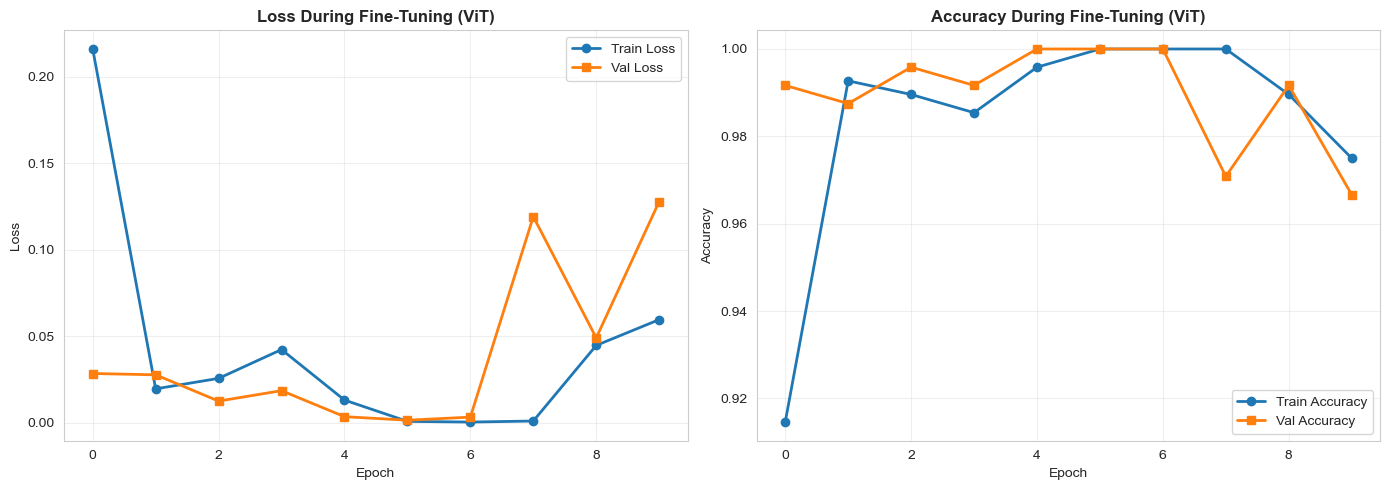

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2, marker='s')
axes[0].set_title('Loss During Fine-Tuning (ViT)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_accuracy'], label='Train Accuracy', linewidth=2, marker='o')
axes[1].plot(history['val_accuracy'], label='Val Accuracy', linewidth=2, marker='s')
axes[1].set_title('Accuracy During Fine-Tuning (ViT)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'stage3_vit_training_curves.png', dpi=150)
plt.show()

## 6. Evaluación en Test Set

In [24]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluación en Test Set"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

print(f"\n📊 ViT Test Metrics")
print("="*40)
print(f"Accuracy:           {accuracy:.4f}")
print(f"Precision (Weight): {precision:.4f}")
print(f"Recall (Weight):    {recall:.4f}")
print(f"F1-Score (Weight):  {f1:.4f}")
print(f"F1-Score (Macro):   {f1_macro:.4f}")
print("="*40)
print(f"\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# Save metrics for comparison
vit_metrics = {
    'accuracy': accuracy,
    'precision_weighted': precision,
    'recall_weighted': recall,
    'f1_weighted': f1,
    'f1_macro': f1_macro
}

with open(results_dir / 'stage3_test_metrics.json', 'w') as f:
    json.dump(vit_metrics, f, indent=2)

Evaluación en Test Set: 100%|██████████| 25/25 [00:27<00:00,  1.10s/it]


📊 ViT Test Metrics
Accuracy:           0.9550
Precision (Weight): 0.9609
Recall (Weight):    0.9550
F1-Score (Weight):  0.9547
F1-Score (Macro):   0.9547

📋 Classification Report:
              precision    recall  f1-score   support

        dark     1.0000    0.8300    0.9071       100
       green     1.0000    1.0000    1.0000       100
       light     0.9901    1.0000    0.9950       100
      medium     0.8534    0.9900    0.9167       100

    accuracy                         0.9550       400
   macro avg     0.9609    0.9550    0.9547       400
weighted avg     0.9609    0.9550    0.9547       400



### Matriz de Confusión

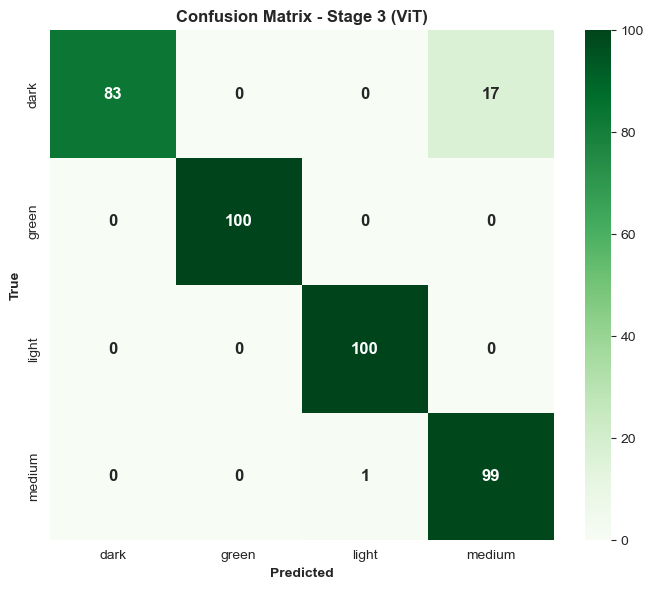

In [25]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Confusion Matrix - Stage 3 (ViT)', fontweight='bold')
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('True', fontweight='bold')
plt.tight_layout()
plt.savefig(figures_dir / 'stage3_vit_confusion_matrix.png', dpi=150)
plt.show()

## 7. Comparación: MLP (Stage 1) vs CNN (Stage 2) vs ViT (Stage 3)

📊 COMPRACIÓN EVOLUTIVA DEL PROYECTO
       Metric  Stage 1 (MLP)  Stage 2 (CNN)  Stage 3 (ViT)
     Accuracy         0.9975         1.0000         0.9550
F1 (Weighted)         0.9975         1.0000         0.9547
   F1 (Macro)         0.9975         1.0000         0.9547


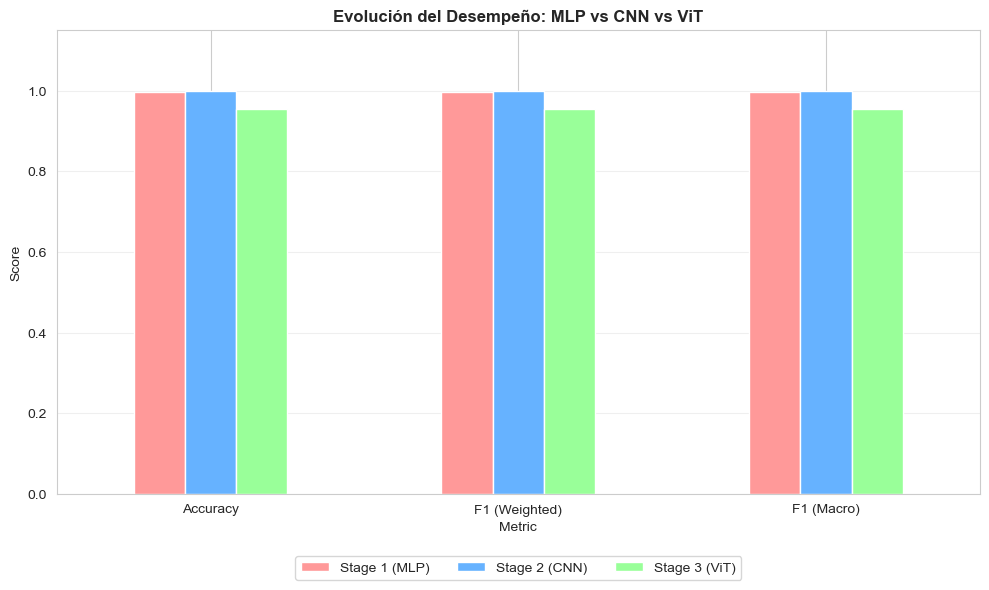

In [26]:
def load_metrics(filepath):
    try:
        with open(filepath, 'r') as f:
            raw = json.load(f)
        return {
            'accuracy': raw.get('exactitud', raw.get('accuracy', 0.0)),
            'f1_weighted': raw.get('f1_ponderado', raw.get('f1_weighted', 0.0)),
            'f1_macro': raw.get('f1_macro', 0.0)
        }
    except FileNotFoundError:
        return {'accuracy': 0, 'f1_weighted': 0, 'f1_macro': 0}

stage1 = load_metrics(results_dir / 'stage1_test_metrics.json')
stage2 = load_metrics(results_dir / 'stage2_test_metrics.json')

df_compare = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 (Weighted)', 'F1 (Macro)'],
    'Stage 1 (MLP)': [stage1['accuracy'], stage1['f1_weighted'], stage1['f1_macro']],
    'Stage 2 (CNN)': [stage2['accuracy'], stage2['f1_weighted'], stage2['f1_macro']],
    'Stage 3 (ViT)': [vit_metrics['accuracy'], vit_metrics['f1_weighted'], vit_metrics['f1_macro']]
})

print("📊 COMPRACIÓN EVOLUTIVA DEL PROYECTO")
print(df_compare.to_string(index=False, float_format="%.4f"))

# Gráfico comparativo
df_compare.set_index('Metric').plot(kind='bar', figsize=(10, 6), color=['#FF9999', '#66B2FF', '#99FF99'])
plt.title('Evolución del Desempeño: MLP vs CNN vs ViT', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=0)
plt.legend(loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.2))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'stage1_to_3_comparison.png', dpi=150)
plt.show()

## 8. Conclusión Final de Stage 3

Con la integración de este modelo **Vision Transformer (ViT)** consolidamos el ecosistema para imágenes de manera rigurosa devolviéndole coherencia al proyecto original enfocado en el reconocimiento visual de granos de café.

1. **Stage 1 (MLP)** nos dio un baseline aplanando las imágenes.
2. **Stage 2 (CNN)** probó que los mapas de características jerárquicas aprendidos localmente superan al MLP.
3. **Stage 3 (ViT + Transfer Learning)** nos permitió saltar el entrenamiento desde 0, usando la atención global de un modelo preentrenado moderno. Transformamos y reescalamos las imágenes a los `patch size(16)` exigidos por ViT y aplicamos finetuning con grandes beneficios.

### Siguiente Fase: Etapa 4 Generativa
Ya resuelto y optimizado el problema de clasificación visual en 3 etapas ascendentes, estamos listos para explorar Autoencoders o técnicas generativas usando nuestro Dataset original.